In [ ]:
# Paso 1: Instala diagrams en Colab si aún no está
!pip install diagrams
!apt-get install graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.4/226.4 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 29.0 MB/s eta 0:00:00
  Attempting uninstall: graphviz
    Found existing installation: graphviz 0.21
    Uninstalling graphviz-0.21:
      Successfully uninstalled graphviz-0.21
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


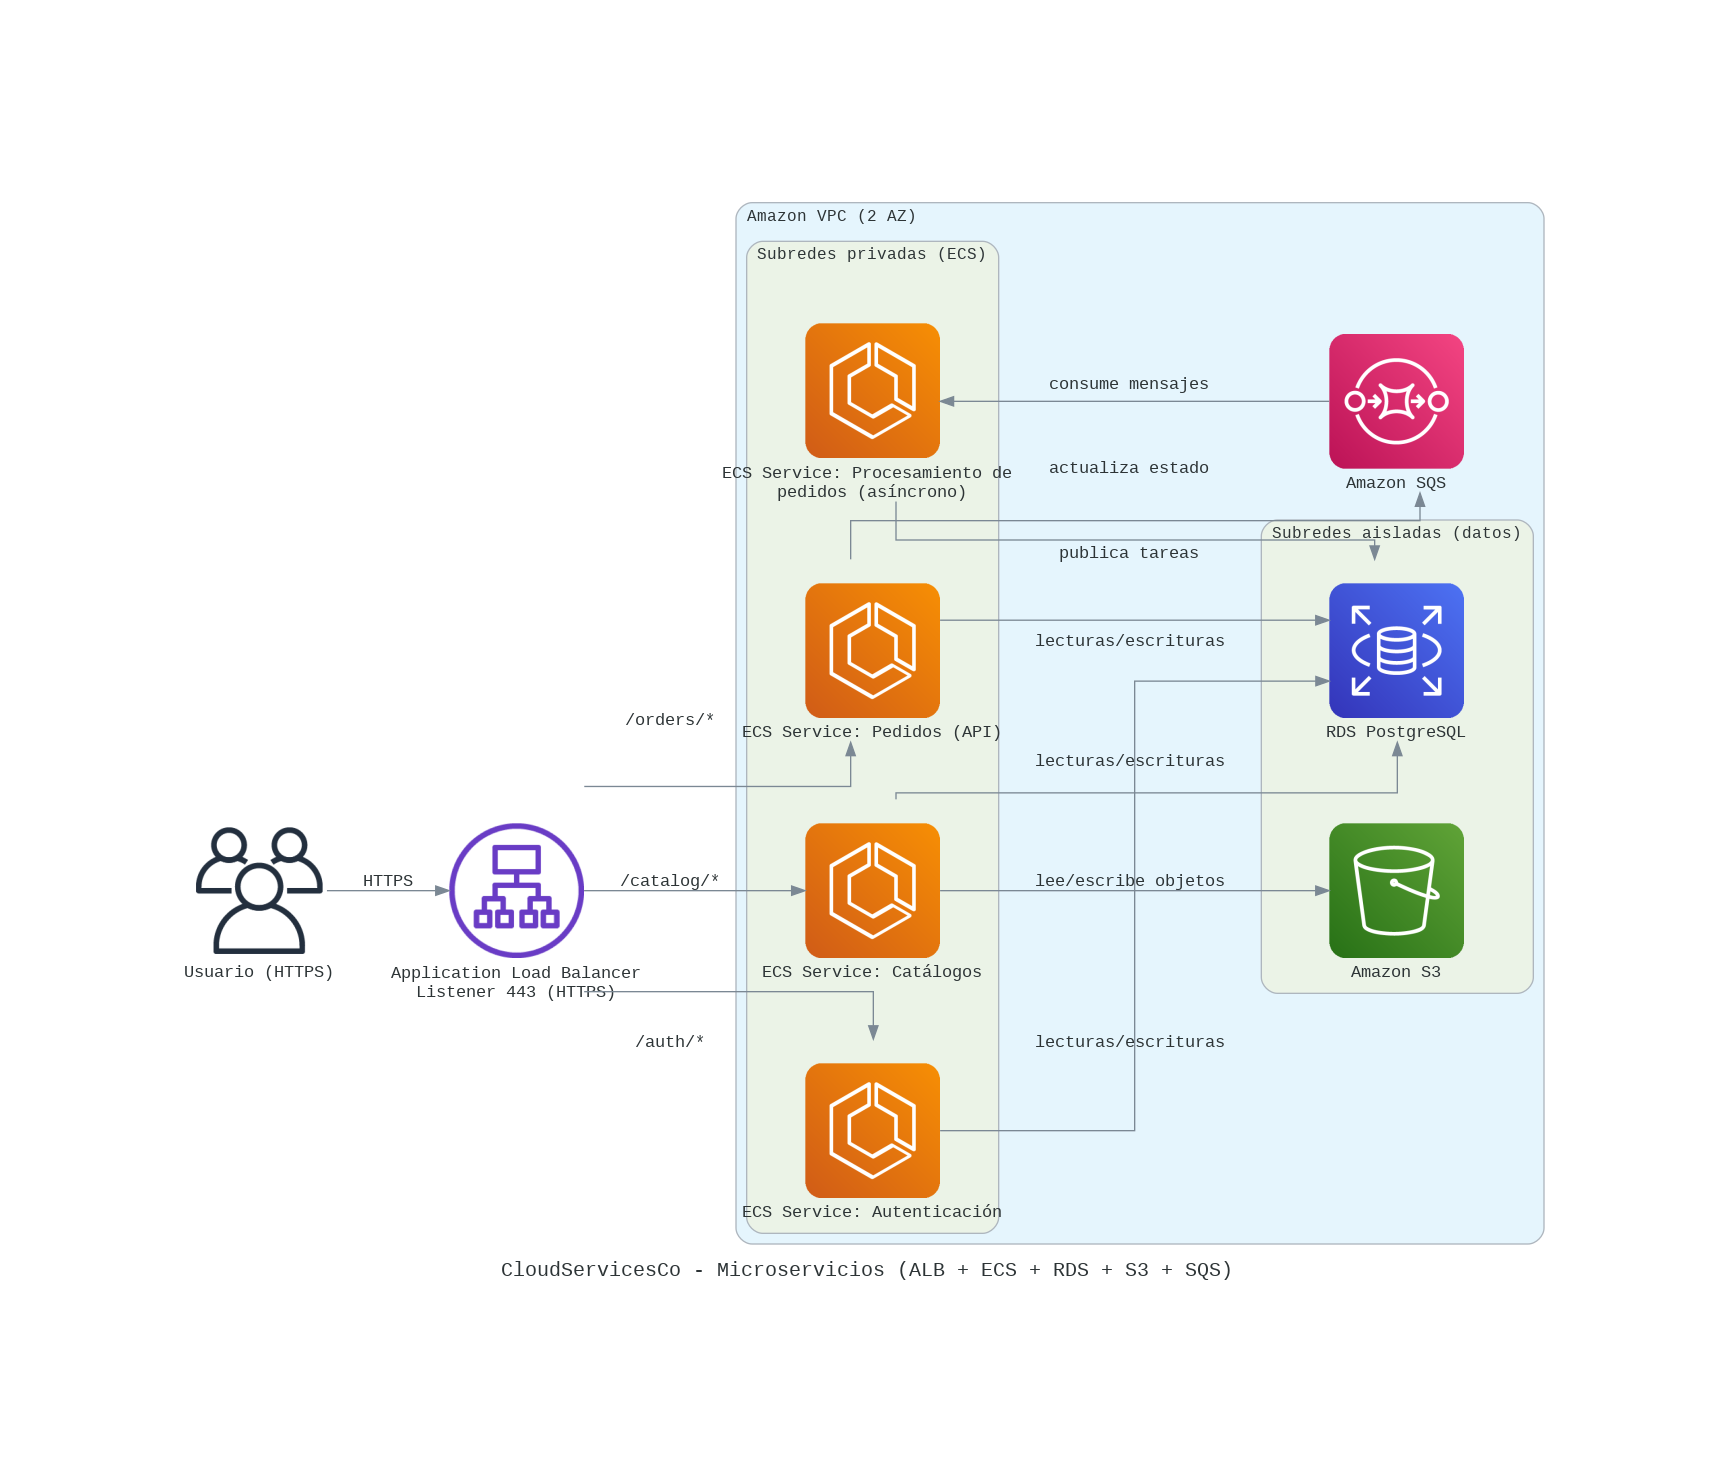

In [ ]:
# Paso 2: Ejecuta este código
from diagrams import Diagram, Cluster, Edge
from diagrams.aws.network import Route53HostedZone, ALB
from diagrams.aws.compute import ECS
from diagrams.aws.database import RDS
from diagrams.aws.storage import S3
from diagrams.aws.integration import SQS
from diagrams.onprem.client import Users
from IPython.display import Image

with Diagram("CloudServicesCo - Microservicios (ALB + ECS + RDS + S3 + SQS)",
             show=False, filename="cloudservicesco_diagram", outformat="png"):

    # Usuario externo
    user = Users("Usuario (HTTPS)")

    # Borde de entrada
    alb = ALB("Application Load Balancer\nListener 443 (HTTPS)")

    # VPC y subredes (lógico/visual)
    with Cluster("Amazon VPC (2 AZ)"):
        with Cluster("Subredes públicas"):
            # ALB vive lógicamente aquí
            alb_node = alb

        with Cluster("Subredes privadas (ECS)"):
            # Microservicios (ECS)
            svc_auth = ECS("ECS Service: Autenticación")
            svc_catalog = ECS("ECS Service: Catálogos")
            svc_orders_api = ECS("ECS Service: Pedidos (API)")
            svc_processing = ECS("ECS Service: Procesamiento de \npedidos (asíncrono)")

        with Cluster("Subredes aisladas (datos)"):
            db = RDS("RDS PostgreSQL")
            bucket = S3("Amazon S3")

        # Cola para desacoplar procesamiento
        sqs = SQS("Amazon SQS")

    # Flujo externo
    user >> Edge(label="HTTPS") >> alb_node

    # Enrutamiento por path desde ALB a cada microservicio
    alb_node >> Edge(label="/auth/*") >> svc_auth
    alb_node >> Edge(label="/catalog/*") >> svc_catalog
    alb_node >> Edge(label="/orders/*") >> svc_orders_api

    # Accesos a datos
    svc_auth >> Edge(label="lecturas/escrituras") >> db
    svc_catalog >> Edge(label="lecturas/escrituras") >> db
    svc_orders_api >> Edge(label="lecturas/escrituras") >> db
    svc_catalog >> Edge(label="lee/escribe objetos") >> bucket

    # Flujo asíncrono de pedidos (sin usar 'worker')
    svc_orders_api >> Edge(label="publica tareas") >> sqs
    sqs >> Edge(label="consume mensajes") >> svc_processing
    svc_processing >> Edge(label="actualiza estado") >> db

# Mostrar imagen generada
Image(filename="cloudservicesco_diagram.png")

In [ ]:
#Para exportar el archivo
from google.colab import files
files.download("cloudservicesco_diagram.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>